In [2]:
import os

import pickle
import re
import json
import pandas as pd
from bertopic import BERTopic
import umap
from tqdm import tqdm
from sentence_transformers import SentenceTransformer

BASE_DIR = r"C:\Users\Orlan\Documents\MDM3\Gaming-AI\Gaming-AI-MDM3"
MODEL_BASE_NAME = "saved_bertopic_model"
EMBEDDINGS_FILENAME = "saved_embeddings.pkl"

def get_new_version_path(base_dir, base_model_name):
    version = input("Enter a new model version name (e.g. v1, v2, etc.): ").strip()
    new_model_path = os.path.join(base_dir, f"{base_model_name}_{version}")
    if os.path.exists(new_model_path):
        print("This version already exists. Please choose a different version name.")
        return get_new_version_path(base_dir, base_model_name)
    return new_model_path

def list_model_versions(base_dir, base_model_name):
    versions = []
    for entry in os.listdir(base_dir):
        full_path = os.path.join(base_dir, entry)
        if os.path.isdir(full_path) and entry.startswith(base_model_name):
            versions.append(full_path)
    return versions

In [ ]:
# Path to save/load the filtered data
reduced_data_path = os.path.join(BASE_DIR, "reduced_data.pkl")

print("Loading filtered data from file...")
with open(reduced_data_path, "rb") as f:
    data, docs = pickle.load(f)

# data = data.head(500)
gids = data['gid'].tolist()
dates = data['date'].tolist()
appId = data['appid'].tolist()

print("Number of patch notes:", len(data))
print(f"Number of unique games: {len(data['appid'].unique())}")

embedding_model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2", device="cuda")

available_models = list_model_versions(BASE_DIR, MODEL_BASE_NAME)
use_saved = False

selected = 1
selected_index = selected - 1
selected_model_path = available_models[selected_index]

print("Embedding documents...")

# ~~ Use if processing new docs (not the docs the model was trained on) ~~
# embeddings = embedding_model.encode(docs, show_progress_bar=True)

embeddings_path = os.path.join(selected_model_path, EMBEDDINGS_FILENAME)

with open(embeddings_path, "rb") as f:
    embeddings = pickle.load(f)

print("Loading saved topic model...")

topic_model = BERTopic.load(selected_model_path)

print("Transforming documents...")
batch_size = 1000
topics = []
for i in tqdm(range(0, len(docs), batch_size), desc="Transforming batches"):
    batch_docs = docs[i:i + batch_size]
    batch_embeddings = embeddings[i:i + batch_size]
    batch_topics, _ = topic_model.transform(batch_docs, embeddings=batch_embeddings)
    topics.extend(batch_topics)

try:
    print("Before Outlier Reduction:\n", topic_model.get_topic_info())
    topics = topic_model.reduce_outliers(docs, topics)
    print("Final Topics:\n", topic_model.get_topic_info())
except ValueError as e:
    if str(e) == "No outliers to reduce.":
        print("No outliers were found to reduce. Skipping outlier reduction.")
    else:
        raise


Loading filtered data from file...
Number of patch notes: 13746
Number of unique games: 109


2025-03-23 17:02:42,323 - BERTopic - WARNING: You are loading a BERTopic model without explicitly defining an embedding model. If you want to also load in an embedding model, make sure to use `BERTopic.load(my_model, embedding_model=my_embedding_model)`.


Embedding documents...
Loading saved topic model...
Transforming documents...


Transforming batches:   0%|          | 0/14 [00:00<?, ?it/s]2025-03-23 17:02:42,358 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.
2025-03-23 17:02:42,394 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.
2025-03-23 17:02:42,401 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.
2025-03-23 17:02:42,408 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.
2025-03-23 17:02:42,418 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.
2025-03-23 17:02:42,420 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.
2025-03-23 17:02:42,432 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.
2025-03-23 17:02:42,438 - BERTopic - Predicting topic assi

Before Outlier Reduction:
    Topic  Count                                        Name  \
0      0   2023         0_gameplay_changelog_turret_weapons   
1      1    490  1_maintenance_scheduled_schedule_transfers   
2      2   1762                  2_issues_crashes_dlc_crash   
3      3   1775          3_combat_missions_gameplay_rewards   
4      4   1400         4_maintenance_hotfix_issues_updated   
5      5    392                 5_dlc_wild_gameplay_weapons   
6      6   1063              6_season_rewards_events_summer   
7      7   1921                7_hotfix_bug_updated_changed   
8      8    377          8_quests_showdown_issues_increased   
9      9   2543       9_gameplay_features_rewards_increased   

                                      Representation  Representative_Docs  
0  [gameplay, changelog, turret, weapons, additio...                  NaN  
1  [maintenance, scheduled, schedule, transfers, ...                  NaN  
2  [issues, crashes, dlc, crash, characters, chan..

In [ ]:
reduced_embeddings = umap.UMAP(n_neighbors=50, n_components=2, metric="cosine", init="random", random_state=42).fit_transform(embeddings)

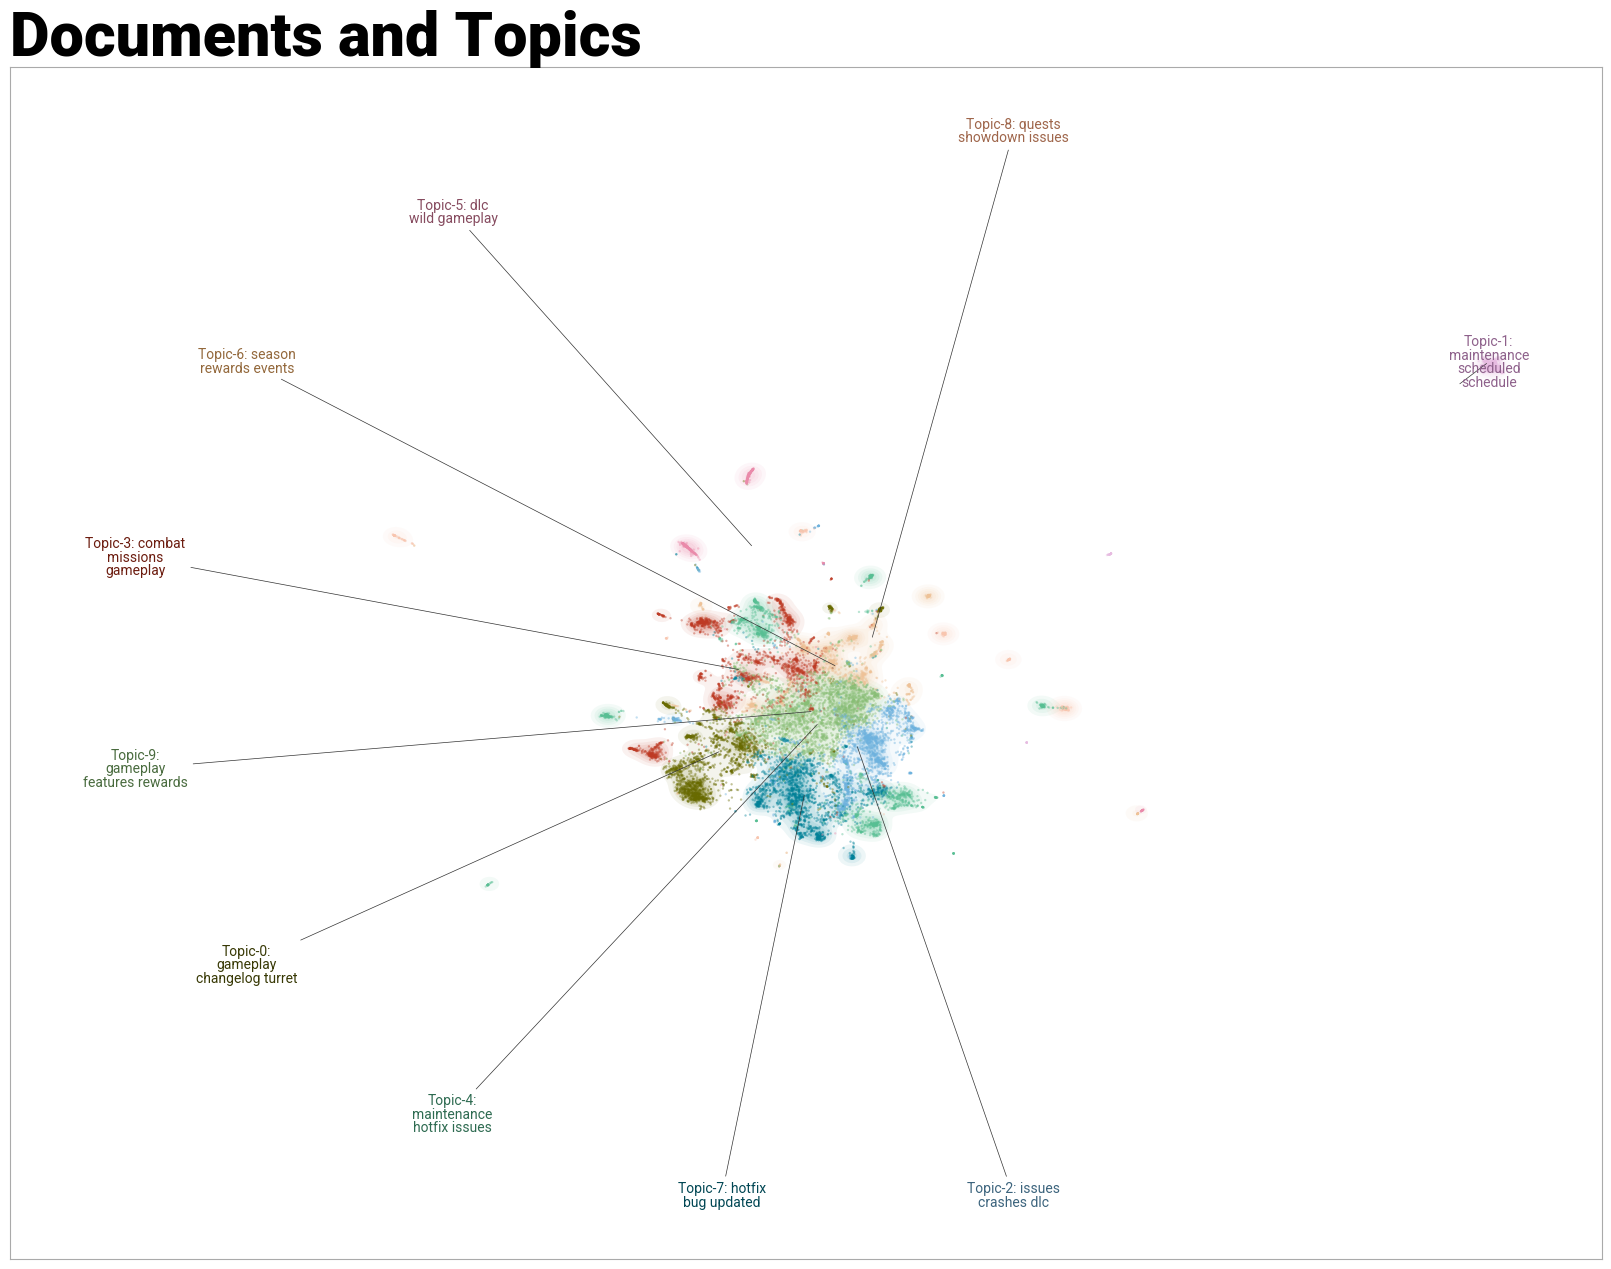

In [33]:
fig = topic_model.visualize_document_datamap(docs, reduced_embeddings=reduced_embeddings, width=1600, height=1200, label_font_size=10, label_margin_factor=0.1)
fig.show()

In [ ]:
# Visualizations
# fig = topic_model.visualize_barchart(top_n_topics=len(topic_model.get_topic_info()))
# fig.show()
# fig = topic_model.visualize_topics()
# fig.show()

# fig = topic_model.visualize_hierarchy()
# fig.show()

topic_model.set_topic_labels({0: "0 - Gameplay", 1: "1 - Scheduled Maintenance", 2: "2- Crash Fix", 3: "3 - Combat Gameplay", 4: "4 - Maintenance", 5: "5 - Seasonal Updates", 6: "6 - dlc", 7: "7 - hotfixes", 8: "8 - Undetermined", 9: "9 - Added features"})
fig = topic_model.visualize_heatmap(custom_labels=True, title="", width=800, height=600)
fig.show()

# fig = topic_model.visualize_documents(docs, embeddings=embeddings, sample=0.5)
# fig.write_html("docs_visualization.html")
# fig.show()

# fig = topic_model.visualize_document_datamap(docs, embeddings=embeddings, label_font_size=12)
# fig.show()